**Hidden Markov Model**

Paulo Yoshio Kuga

In this notebook, we are going to show how to train the HMM model with the processed data.

In [1]:
#import libraries

import pandas as pd
from matplotlib import pyplot as plt
import numpy as np

from wakaranaihmm import State, HsMM, GaussianEmission, GammaEmission, PoissonDuration

import lissa as li

import json
from sklearn.mixture import GaussianMixture

First we import the processed data, filling the NaN with zeros. Then we convert the time as a time dtype.

In [2]:
#You also can read data without processing it always:

total_data = pd.read_csv("../data/totalProcessedData.csv",delimiter=",").fillna(0)
total_data["time"] = pd.to_datetime(total_data["time"])
total_data.set_index("time",inplace=True)

C:\Users\Protocolo\AppData\Local\Temp\ipykernel_13728\3032592086.py:3: DtypeWarning: Columns (14,15) have mixed types. Specify dtype option on import or set low_memory=False.
  total_data = pd.read_csv("../data/totalProcessedData.csv",delimiter=",").fillna(0)


Then we can read the numerical properties from a dictionary and find the list of runs (or pumps) contained in the data.

In [3]:
with open("./dictionaries/new_headers.json") as dict:
    operational_headers = json.load(dict)["numerical_headers"]

pump_list = total_data["Well Run"].unique()

Later, we set a seed to our random numbers, and calculate some properties. Instead of opened choke, we can calculate de closed choke. Moreover, we can calculate the "Radius" which is the euclidean norm of the numerical properties. This measure can state how far the datum were from its median.

After that, we can split the data. It is noticed that we are not using the standard train_test_split function from sklearn. This function splitter (which should be refatorated to a proper Python convention - PEP 8) selects a proportion of 75% of each run listed in data. 

Nonetheless, the time-series are separated by the time that they were online or offline. In the end, for each pump it is possible to have samples of online stochastic processes that are going to feed the markov model.



In [4]:
main_seed = 19971215
np.random.seed(main_seed)

total_data["Choke Closed"] = 1-total_data["Choke Opening"]
total_data["Radius"] = total_data[operational_headers].pow(2).sum(axis=1).pow(1/2)

X_train, train_length, X_test, test_length, model_data, total_length = li.Splitter(pumpList=pump_list,proportion=0.75,entireData=total_data)

Next, we can fit the Gaussian Mixture Model...

In [5]:
n = 3
radiusData = X_train["Radius"].loc[X_train["Well_down"]==0]
radius_data_np = li.check_data(radiusData)

model_gmm = GaussianMixture(n_components=n,random_state=main_seed)
model_gmm.fit(radius_data_np)

,n_components,3
,covariance_type,'full'
,tol,0.001
,reg_covar,1e-06
,max_iter,100
,n_init,1
,init_params,'kmeans'
,weights_init,None
,means_init,None
,precisions_init,None
,random_state,19971215


In [18]:
model_hsmm_gamma = HsMM(
    states=[
    State(emission=GaussianEmission(),duration=PoissonDuration(),name="Normal"),
    State(emission=GaussianEmission(),duration=PoissonDuration(),name="Anômalo"),
    ],
    random_state=20000728
    )

model_hsmm_gamma.fit(li.check_data(X_train["Radius"]),train_length)

After this, we can post-process the models data, and reaching the stationary distribution of the model.

In [19]:
total_data, model_data = li.PostProcessing(model_hsmm_gamma, total_data, model_data,"Radius", "Estados HsMM Gamma", total_length)

stationary = model_hsmm_gamma.stationary_distribution()
print(stationary)


total_data["Estados HsMM Gamma"] = total_data["Estados HsMM Gamma"].map(li.StateConversion(stationary,n))




[0.48211075 0.51788925]


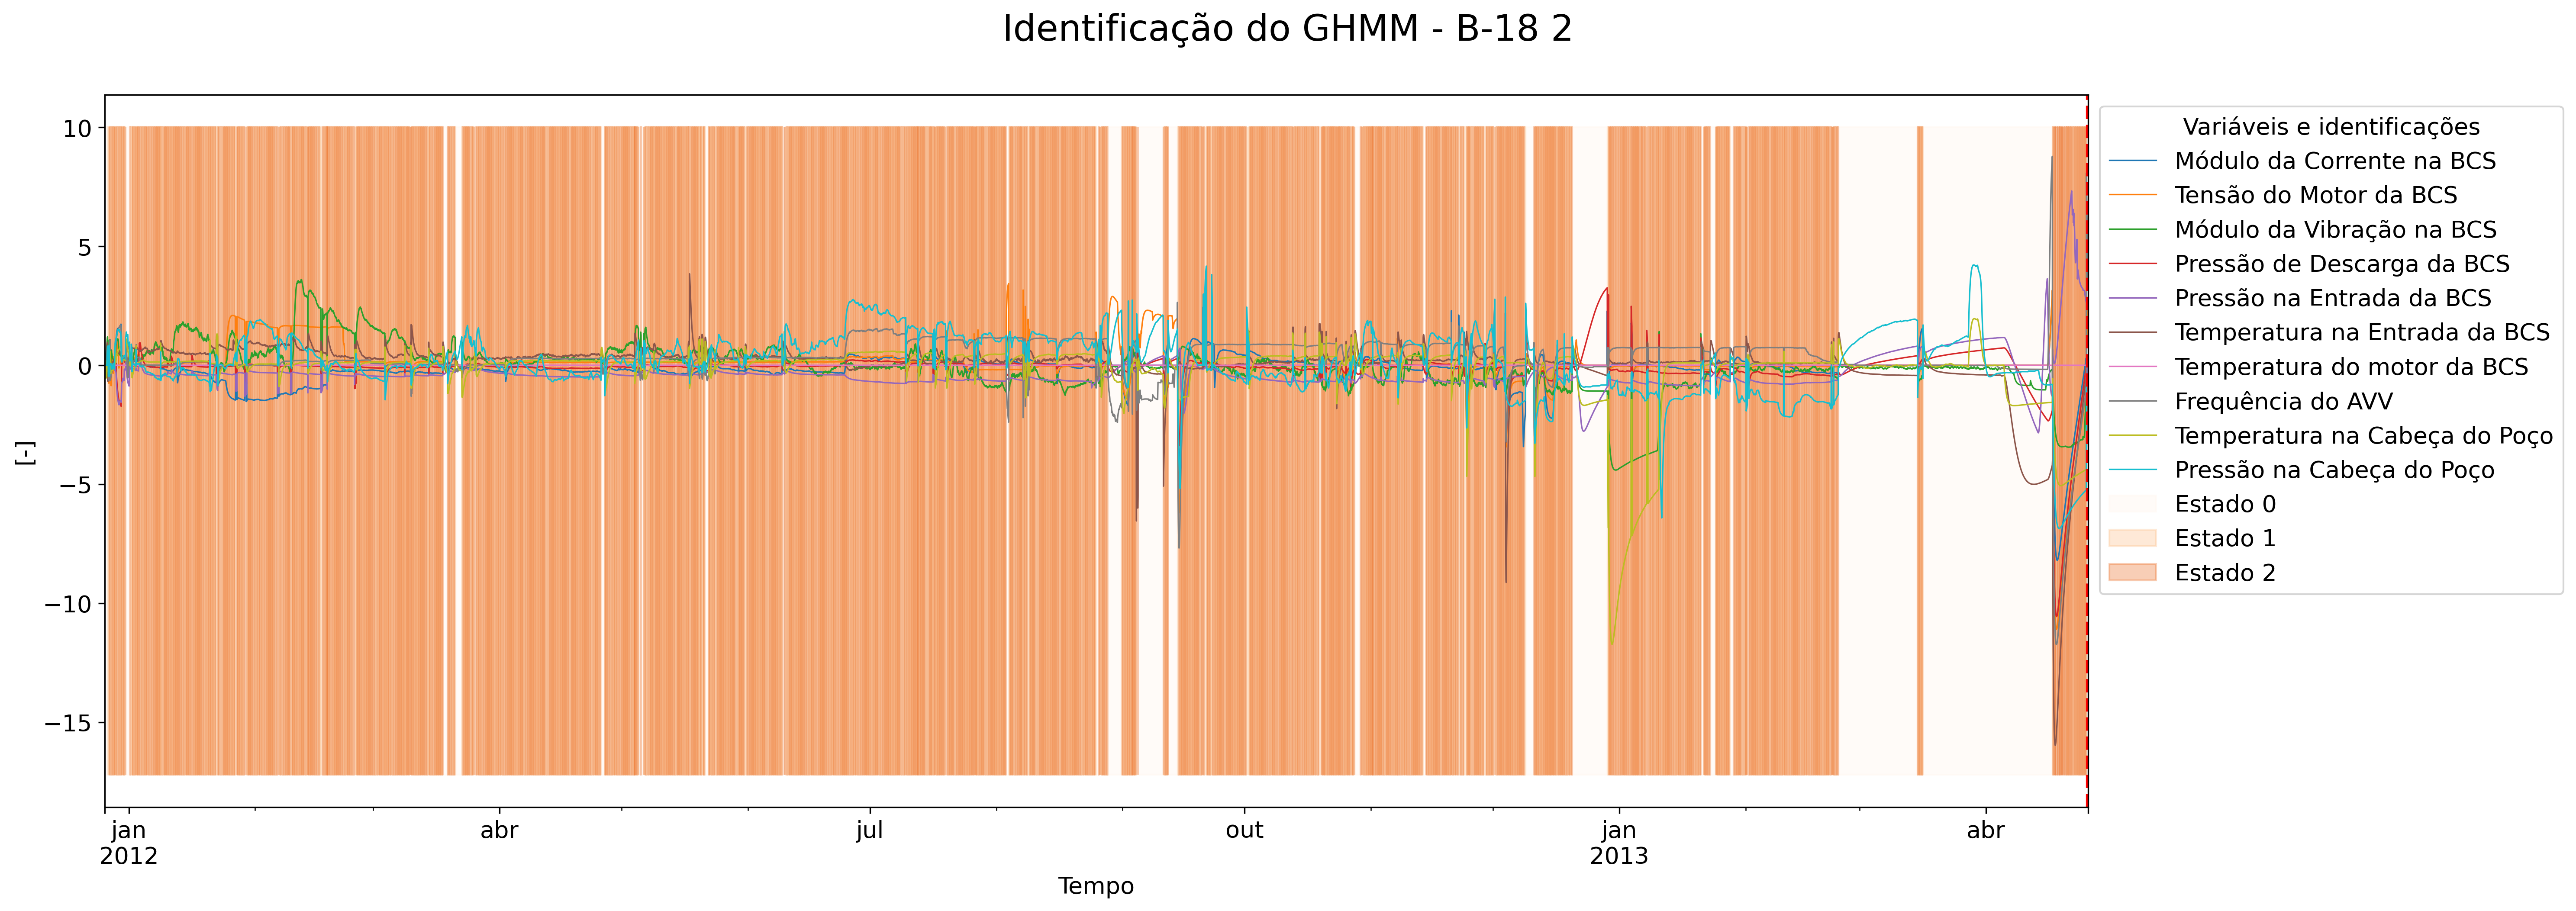

In [20]:
pump = "B-18 2"

pumpData = total_data.loc[total_data["Well Run"]==pump].copy()
pumpData = pumpData.asfreq('h',fill_value=0)

where_change = (pumpData["Failure"]==True).diff()

where_change.iloc[0] = False

figure = (li.LissaFigure("./plots/hmm_plot.json")
    .set_translation()
    .set_figure()
    .time_series_plot(data=pumpData,line_width=0.8))

if where_change.sum() != 0:
    failure_index = pumpData.index[where_change][0]
    figure = figure.failure_reference(time_entry=failure_index,linewidth=2)

figure = (
    figure
    .classification_boundaries(n,pumpData["Estados HsMM Gamma"])
    .set_legends()
    .set_axes_texts()
    .finalize(title="Identificação do GHMM - "+pump))